# GBPUSD vs EURUSD — 2025 multi-month validation

**Phase 1**: same minimal pipeline as the Jan-25 mini-run (3-day rolling train → 1-day OOS, EOD flat, fixed trading-rule params), now run independently on **Jan, Feb, Mar, Apr, May 2025** to see whether the MS_AR edge survives across months. Final cell sweeps the trading-rule knobs on one chosen month.

In [25]:
!curl -sL https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py -o /content/colab.py
import sys; sys.path.insert(0, '/content'); from colab import setup; setup('code/jan2025')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/jan2025
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [26]:
%pip install --quiet arch optuna

import itertools, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [27]:
# ---- Pair ----
NAME_A, NAME_B = 'GBPUSD', 'EURUSD'
PAIR_NAME      = f'{NAME_A}_{NAME_B}'
DATA_DIR       = '../data/processed'

# ---- Bar aggregation ----
# threshold=500 (vs 1000 in the big notebooks) gives ~2x more bars per day,
# which is what makes a 3-day training window viable for the HMM.
START_HOUR, END_HOUR = 0, 24
BAR_THRESHOLD        = 500

# ---- Engine (per-day rolling fit) ----
TRAIN_DAYS    = 3       # rolling training history
COINT_WINDOW  = 150     # rolling OLS window for beta/alpha
Z_WINDOW      = 50      # rolling z-score lookback
K_REGIMES     = 2       # quiet vs danger
WINSORIZE_STD = 4.0
SCALING       = 10000

# ---- Backtester trading-rule params (fixed; no WFO inside a one-month slice) ----
Z_QUIET          = 1.3
Z_VOLATILE       = 2.5
EXIT_Z           = 0.0
DANGER_THRESHOLD = 0.30
FEE_BPS          = 0.5
SLIPPAGE_MODE    = 'half_spread'

# Treat each day as an independent trade: positions reset at EOD.
FLATTEN_EOD = True

# Tick-clock annualisation factor for Sharpe (matches WFO._ANN_FACTOR)
_ANN_FACTOR = 252 * 24 * 60

In [28]:
def make_files(name_a, name_b, months):
    a, b = name_a.lower(), name_b.lower()
    return [
        [f'{DATA_DIR}/{a}_dukascopy_ask_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{a}_dukascopy_bid_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{b}_dukascopy_ask_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{b}_dukascopy_bid_{m}.parquet' for m in months],
    ]

def sharpe(r):
    r = r.fillna(0); s = r.std()
    return float(r.mean() / s * np.sqrt(_ANN_FACTOR)) if (s > 0 and np.isfinite(s)) else 0.0

def run_pipeline(month, verbose=True):
    """Build spread → engine walk-forward → backtest. Returns (results, df_params)."""
    builder = SPREAD(agg_type='tick', threshold=BAR_THRESHOLD,
                     active_hours=(START_HOUR, END_HOUR))
    df = builder.build(make_files(NAME_A, NAME_B, [month]))
    if verbose:
        print(f'  bars={len(df):,}  days={df.index.normalize().unique().shape[0]}')

    live, df_params = ENGINE.walk_forward(
        df=df,
        train_days=TRAIN_DAYS, coint_window=COINT_WINDOW, z_window=Z_WINDOW,
        k_regimes=K_REGIMES, winsorize_std=WINSORIZE_STD, scaling=SCALING,
        print_freq=10**6,   # silence per-day prints
    )

    bt = BACKTESTER(live)
    results = bt.run(
        z_quiet=Z_QUIET, z_volatile=Z_VOLATILE, exit_z=EXIT_Z,
        danger_threshold=DANGER_THRESHOLD,
        fee_bps=FEE_BPS, slippage_mode=SLIPPAGE_MODE,
        flatten_eod=FLATTEN_EOD,
    )
    return results, df_params

def month_metrics(results):
    out = {}
    for strat in ('Baseline', 'AR', 'MS_AR'):
        r = results[f'Return_{strat}'].fillna(0)
        out[f'{strat}_Sharpe'] = sharpe(r)
        out[f'{strat}_PnLbps'] = float(r.sum() * 1e4)
        out[f'{strat}_Trades'] = int((results[f'Target_{strat}'].diff().abs() > 0).sum() / 2)
    return out

In [29]:
TEST_MONTHS = ['202501', '202502', '202503', '202504', '202505']

all_runs    = {}
all_metrics = []
for m in TEST_MONTHS:
    print(f'\n--- {m} ---')
    try:
        results, df_params = run_pipeline(m)
        all_runs[m] = (results, df_params)
        mm = month_metrics(results); mm['Month'] = m
        all_metrics.append(mm)
        print(f'  Sharpe  Baseline={mm["Baseline_Sharpe"]:+.2f}  '
              f'AR={mm["AR_Sharpe"]:+.2f}  MS_AR={mm["MS_AR_Sharpe"]:+.2f}')
    except Exception as e:
        print(f'  FAILED: {type(e).__name__}: {e}')

summary = pd.DataFrame(all_metrics).set_index('Month')


--- 202501 ---
built 5288 rows
  bars=5,288  days=23
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+38.41  AR=+16.56  MS_AR=+25.80

--- 202502 ---
built 4331 rows
  bars=4,331  days=20
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+28.59  AR=-2.11  MS_AR=+24.25

--- 202503 ---
built 4078 rows
  bars=4,078  days=21
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+5.05  AR=-24.84  MS_AR=+8.30

--- 202504 ---
built 7157 rows
  bars=7,157  days=22
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  Sharpe  Baseline=+9.62  AR=-6.59  MS_AR=+7.34

--- 202505 ---
built 3897 rows
  bars=3,897  days=22
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
  

In [30]:
print('=== SHARPE BY MONTH (tick-clock annualised) ===')
print(summary[['Baseline_Sharpe', 'AR_Sharpe', 'MS_AR_Sharpe']].round(2).to_string())

print('\n=== PnL bps BY MONTH ===')
print(summary[['Baseline_PnLbps', 'AR_PnLbps', 'MS_AR_PnLbps']].round(1).to_string())

print('\n=== TRADES BY MONTH ===')
print(summary[['Baseline_Trades', 'AR_Trades', 'MS_AR_Trades']].to_string())

edge = pd.DataFrame({
    'MS_AR vs Baseline': summary['MS_AR_Sharpe'] - summary['Baseline_Sharpe'],
    'MS_AR vs AR':       summary['MS_AR_Sharpe'] - summary['AR_Sharpe'],
})
print('\n=== EDGE: MS_AR Sharpe minus baseline ===')
print(edge.round(2).to_string())

wins_base = (edge['MS_AR vs Baseline'] > 0).sum()
wins_ar   = (edge['MS_AR vs AR']       > 0).sum()
n = len(edge)
print(f'\nMS_AR beat Baseline in {wins_base}/{n} months  |  MS_AR beat AR in {wins_ar}/{n} months')
print('Phase 1 verdict: edge is robust if MS_AR beats AR in >= 3/{n} months (and ideally Baseline too).'.format(n=n))

=== SHARPE BY MONTH (tick-clock annualised) ===
        Baseline_Sharpe  AR_Sharpe  MS_AR_Sharpe
Month                                           
202501            38.41      16.56         25.80
202502            28.59      -2.11         24.25
202503             5.05     -24.84          8.30
202504             9.62      -6.59          7.34
202505            10.33      -1.53          2.39

=== PnL bps BY MONTH ===
        Baseline_PnLbps  AR_PnLbps  MS_AR_PnLbps
Month                                           
202501           1102.9      191.6         633.7
202502            431.4      -15.7         297.4
202503             70.1      -61.2          82.3
202504            311.0      -79.8         203.0
202505            171.0       -8.5          30.7

=== TRADES BY MONTH ===
        Baseline_Trades  AR_Trades  MS_AR_Trades
Month                                           
202501              267        147           164
202502              163        115            91
202503             


==============================  202501  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -70.90         | 1102.86        | 191.59         | 633.74         |
Annual Return (bps)            | -1035.78       | 16112.74       | 2799.19        | 9258.89        |
Best Month (bps)               | -70.90         | 1102.86        | 191.59         | 633.74         |
Worst Month (bps)              | -70.90         | 1102.86        | 191.59         | 633.74         |
Positive Months %              | 0.00%          | 100.00%        | 100.00%        | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 1190.78        | 942.41         | 379.66         | 806.12         |
Max

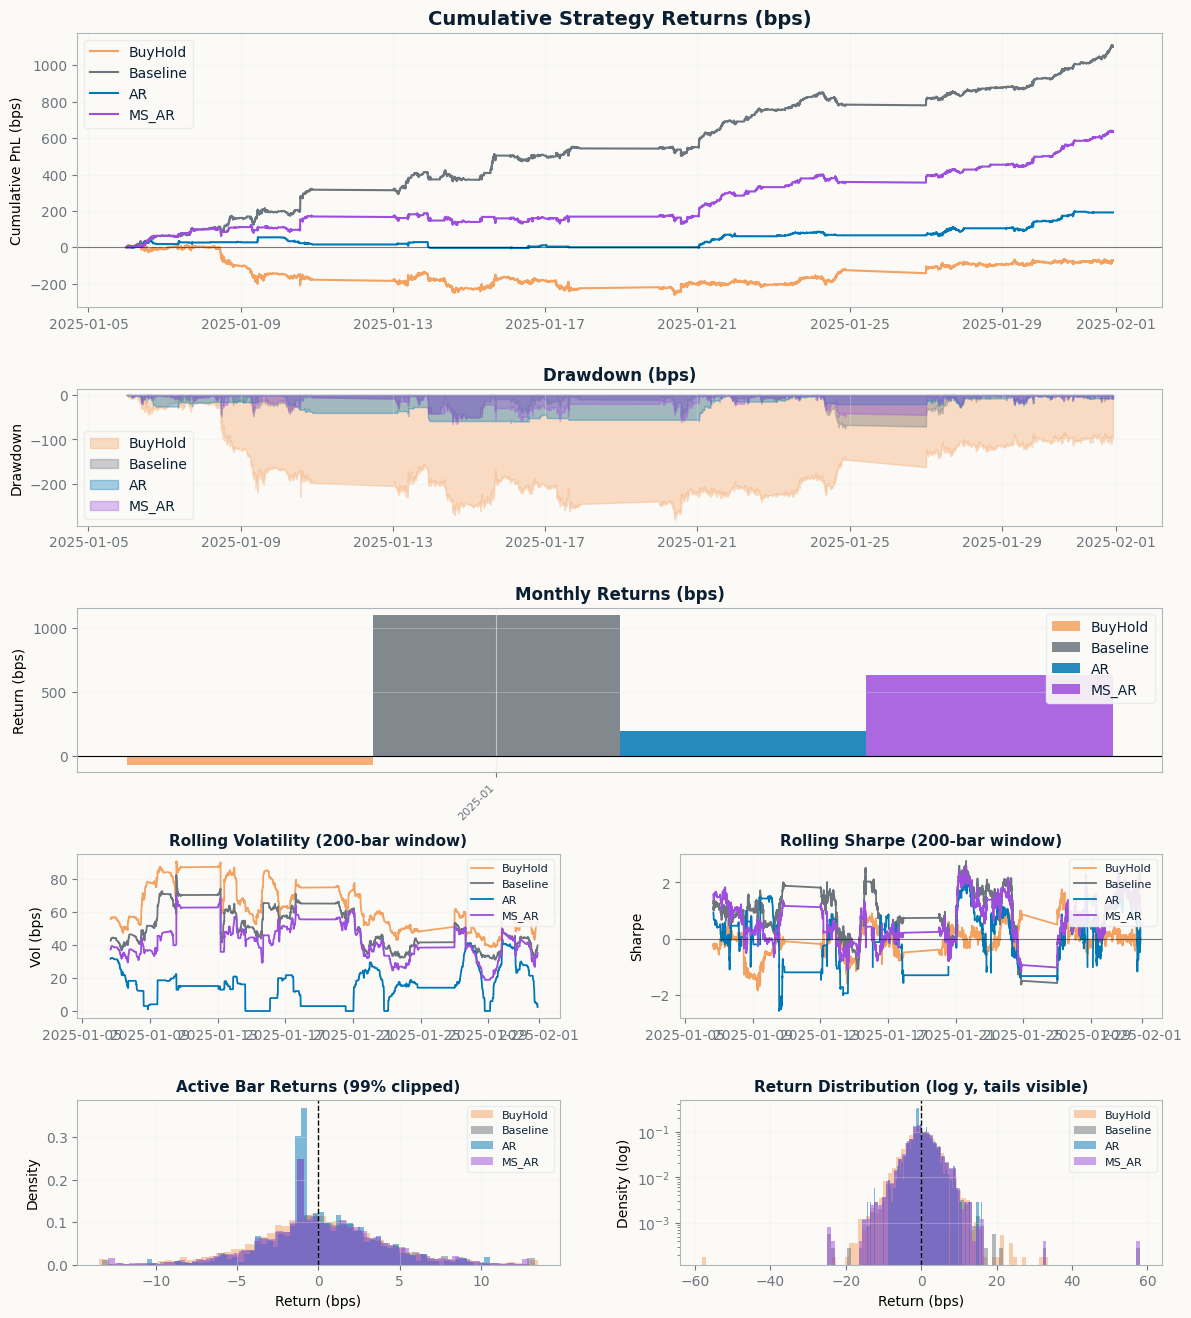


==============================  202502  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -74.99         | 431.41         | -15.71         | 297.37         |
Annual Return (bps)            | -1244.94       | 7162.38        | -260.80        | 4936.99        |
Best Month (bps)               | -74.99         | 431.41         | -15.71         | 297.37         |
Worst Month (bps)              | -74.99         | 431.41         | -15.71         | 297.37         |
Positive Months %              | 0.00%          | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 823.01         | 639.40         | 315.73         | 519.55         |
Max

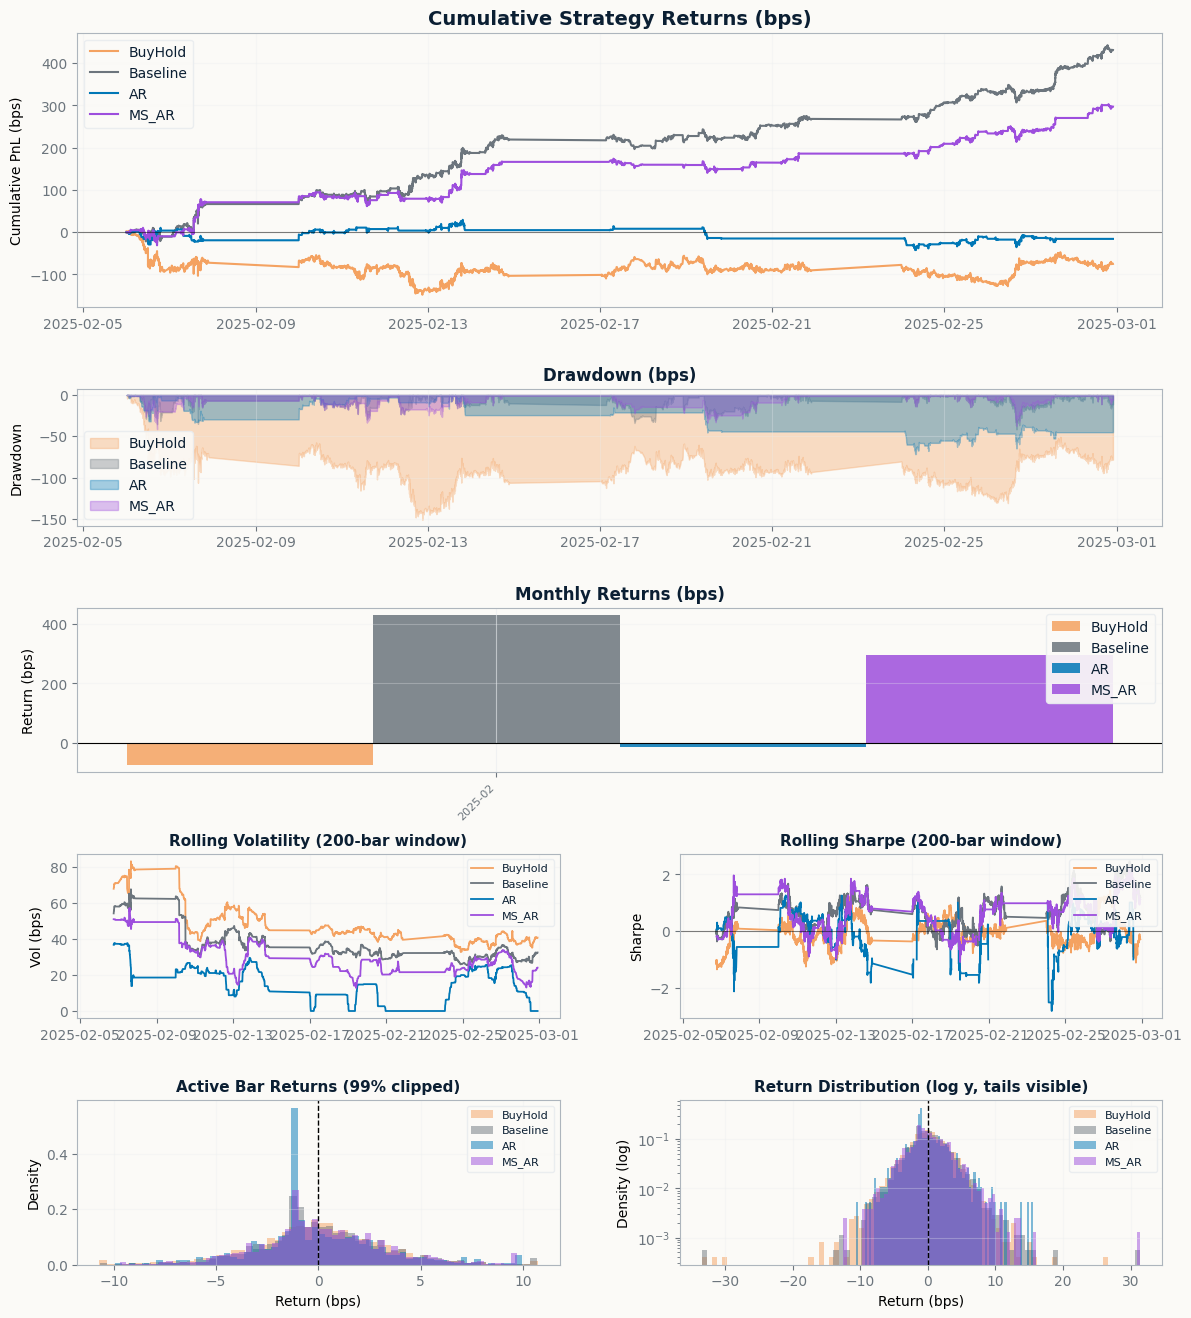


==============================  202503  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 55.75          | 70.07          | -61.22         | 82.31          |
Annual Return (bps)            | 814.56         | 1023.78        | -894.44        | 1202.48        |
Best Month (bps)               | 55.75          | 70.07          | -61.22         | 82.31          |
Worst Month (bps)              | 55.75          | 70.07          | -61.22         | 82.31          |
Positive Months %              | 100.00%        | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 687.74         | 564.46         | 100.17         | 403.18         |
Max

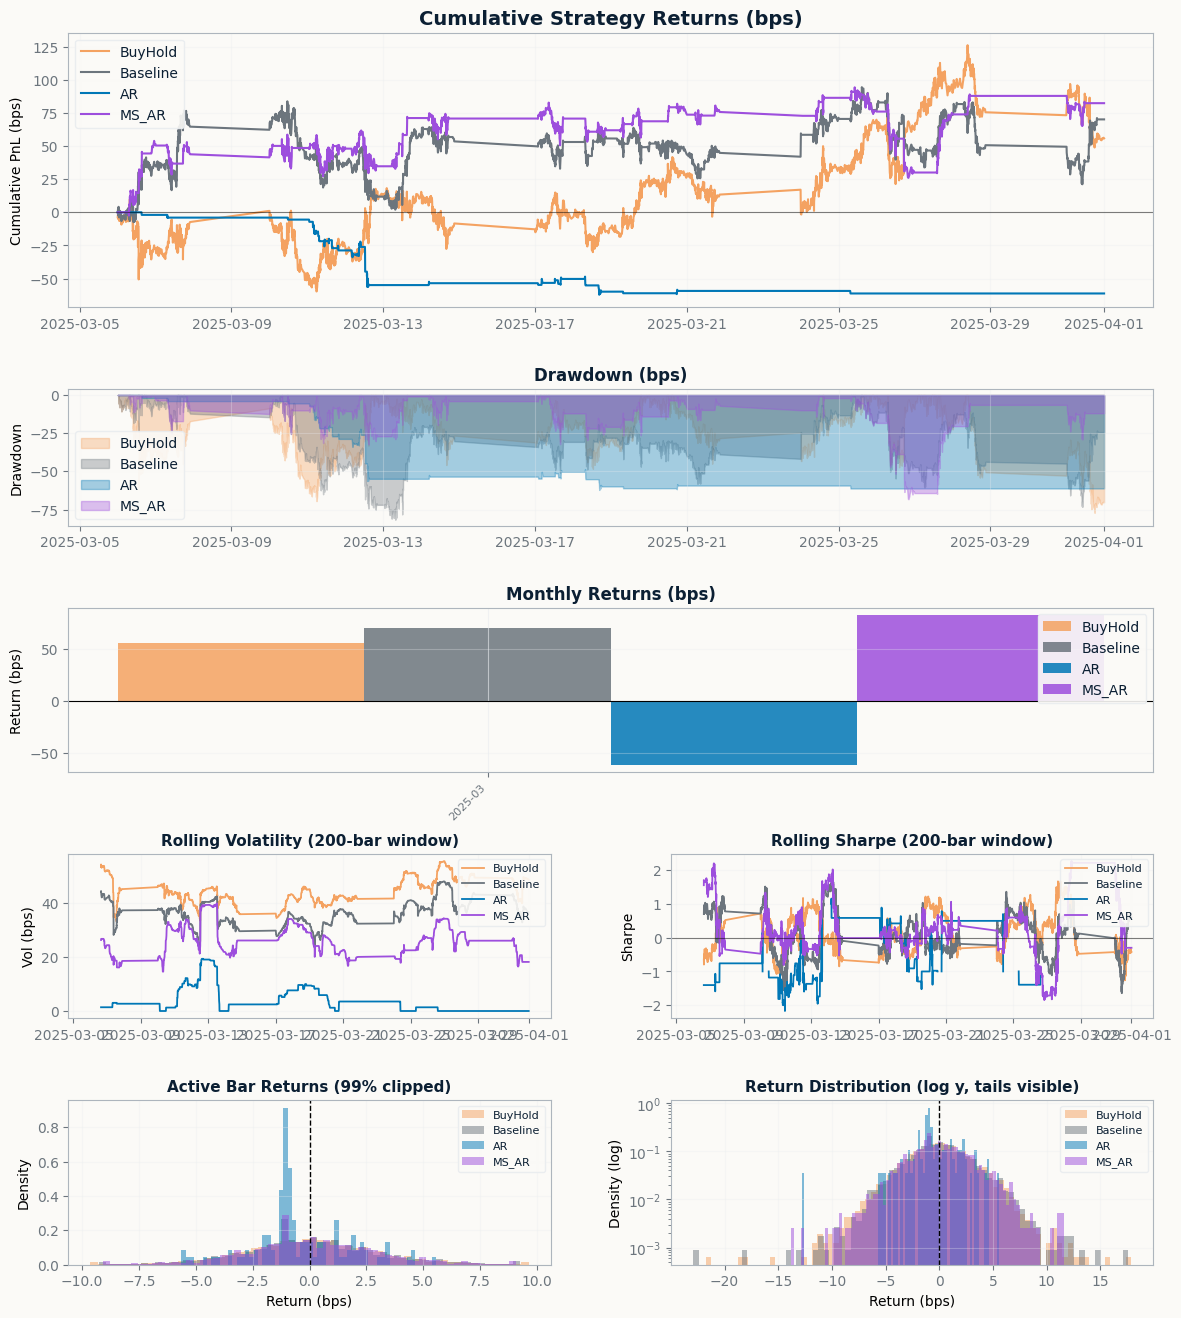


==============================  202504  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 24.54          | 311.00         | -79.79         | 202.99         |
Annual Return (bps)            | 344.73         | 4368.96        | -1120.96       | 2851.65        |
Best Month (bps)               | 24.54          | 311.00         | -79.79         | 202.99         |
Worst Month (bps)              | 24.54          | 311.00         | -79.79         | 202.99         |
Positive Months %              | 100.00%        | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 1109.75        | 911.90         | 341.71         | 780.60         |
Max

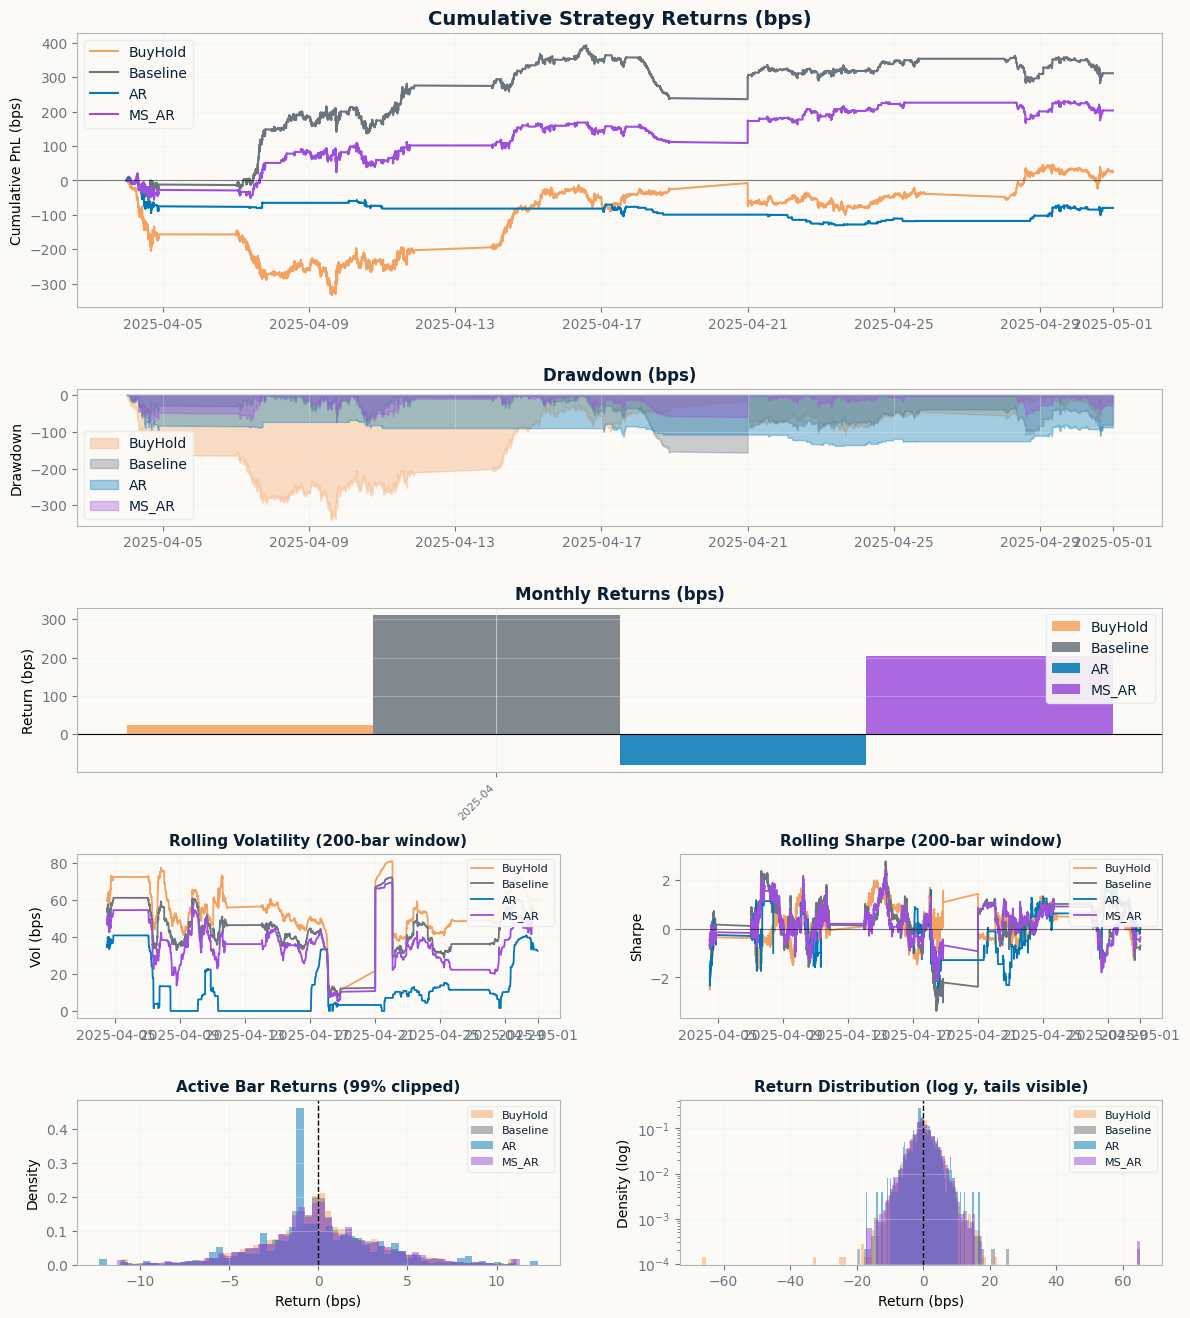


==============================  202505  ==============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 114.17         | 170.97         | -8.49          | 30.71          |
Annual Return (bps)            | 1737.47        | 2601.88        | -129.27        | 467.42         |
Best Month (bps)               | 114.17         | 170.97         | -8.49          | 30.71          |
Worst Month (bps)              | 114.17         | 170.97         | -8.49          | 30.71          |
Positive Months %              | 100.00%        | 100.00%        | 0.00%          | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 790.46         | 665.78         | 223.97         | 517.12         |
Max

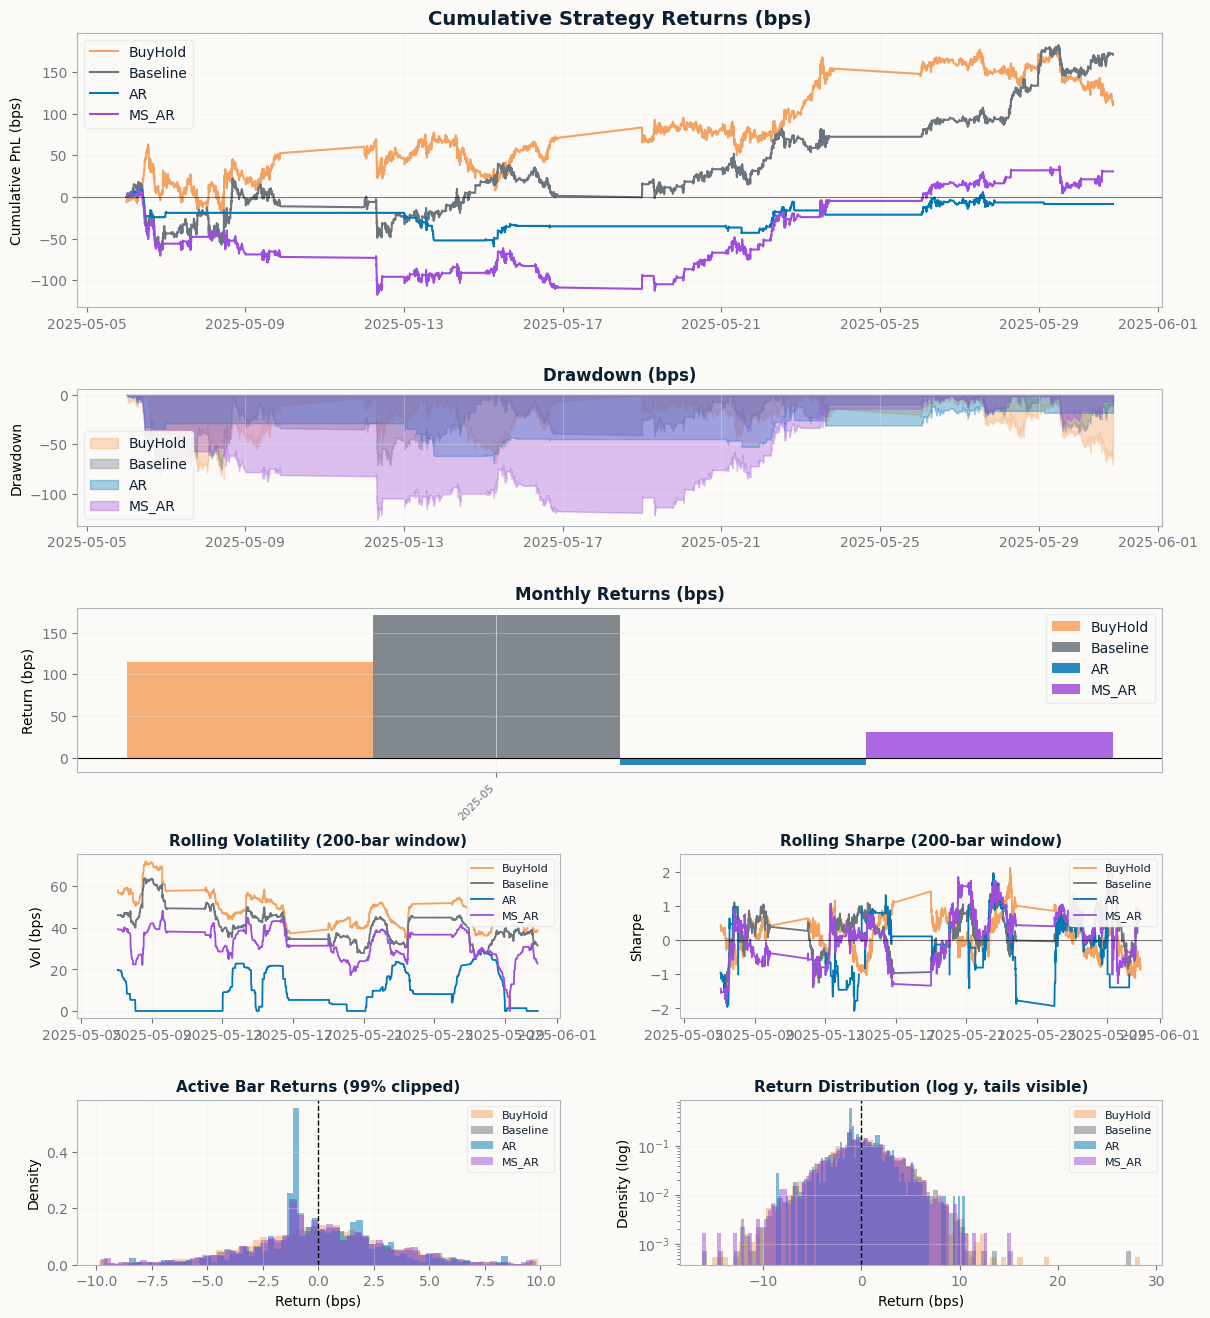

In [31]:
# Per-month full reports + equity curve. Comment out months you don't care about.
for m in TEST_MONTHS:
    if m not in all_runs:
        continue
    results, df_params = all_runs[m]
    print(f'\n{"="*30}  {m}  {"="*30}')
    ts = TEARSHEET(results, df_params=df_params, pdf_prefix=f'{PAIR_NAME}_{m}')
    ts.generate_report()
    ts.plot_performance()

In [32]:
# Sensitivity sweep: vary the trading-rule knobs only (engine output is fixed).
# 3x3x3 = 27 fast backtests. Tells us whether the MS_AR result is param-fitted.
SWEEP_MONTH = '202501'

builder = SPREAD(agg_type='tick', threshold=BAR_THRESHOLD,
                 active_hours=(START_HOUR, END_HOUR))
df_sw = builder.build(make_files(NAME_A, NAME_B, [SWEEP_MONTH]))
live_sw, _ = ENGINE.walk_forward(
    df=df_sw, train_days=TRAIN_DAYS, coint_window=COINT_WINDOW,
    z_window=Z_WINDOW, k_regimes=K_REGIMES,
    winsorize_std=WINSORIZE_STD, scaling=SCALING, print_freq=10**6,
)

Z_QUIET_GRID    = [1.0, 1.3, 1.6]
Z_VOLATILE_GRID = [2.0, 2.5, 3.5]
DTHRESH_GRID    = [0.15, 0.30, 0.50]

rows = []
for zq, zv, dt in itertools.product(Z_QUIET_GRID, Z_VOLATILE_GRID, DTHRESH_GRID):
    res = BACKTESTER(live_sw).run(
        z_quiet=zq, z_volatile=zv, exit_z=EXIT_Z, danger_threshold=dt,
        fee_bps=FEE_BPS, slippage_mode=SLIPPAGE_MODE, flatten_eod=FLATTEN_EOD,
    )
    rows.append({
        'z_quiet': zq, 'z_volatile': zv, 'danger_threshold': dt,
        'Baseline_Sharpe': sharpe(res['Return_Baseline']),
        'AR_Sharpe':       sharpe(res['Return_AR']),
        'MS_AR_Sharpe':    sharpe(res['Return_MS_AR']),
        'MS_AR_Trades':    int((res['Target_MS_AR'].diff().abs() > 0).sum() / 2),
    })

sweep_df = pd.DataFrame(rows)
sweep_df['MS_AR_vs_AR']       = sweep_df['MS_AR_Sharpe'] - sweep_df['AR_Sharpe']
sweep_df['MS_AR_vs_Baseline'] = sweep_df['MS_AR_Sharpe'] - sweep_df['Baseline_Sharpe']

print(f'=== Sensitivity sweep, {SWEEP_MONTH}, {PAIR_NAME} ===')
print(sweep_df.round(2).to_string(index=False))

print(f'\nMS_AR > AR       across grid: {(sweep_df["MS_AR_vs_AR"]       > 0).sum()}/{len(sweep_df)}')
print(f'MS_AR > Baseline across grid: {(sweep_df["MS_AR_vs_Baseline"] > 0).sum()}/{len(sweep_df)}')

built 5288 rows
Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000
=== Sensitivity sweep, 202501, GBPUSD_EURUSD ===
 z_quiet  z_volatile  danger_threshold  Baseline_Sharpe  AR_Sharpe  MS_AR_Sharpe  MS_AR_Trades  MS_AR_vs_AR  MS_AR_vs_Baseline
     1.0         2.0              0.15            41.83      14.87         33.18           226        18.31              -8.65
     1.0         2.0              0.30            41.83      18.63         33.18           226        14.54              -8.65
     1.0         2.0              0.50            41.83      23.07         33.18           226        10.10              -8.65
     1.0         2.5              0.15            41.83      14.87         26.82           192        11.95             -15.01
     1.0         2.5              0.30            41.83      18.63         26.82           192         8.18             -15.01
     1.0         2.5              0.50            41.83      23.07 